In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
# --- STEP 1: DATA LOADING & UNDERSTANDING ---
train_df=pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [3]:
#Combine train/test dataset & reset index for consistent cleaning/engineering
data = pd.concat([train_df,test_df], sort=False).reset_index(drop=True)

In [4]:
# Display the first 5 rows to inspect data structure
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
#Understanding the Data
print(data.shape)

print(".........................................................................")

print(data.info())

print(".........................................................................")

print(data.describe())

print(".........................................................................")

print(data.isnull().sum())

print(".........................................................................")


print(data["Survived"].value_counts())

(1309, 12)
.........................................................................
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB
None
.........................................................................
       PassengerId    Survived       Pclass          Age        SibSp  \
coun

In [6]:
# --- STEP 2: DATA CLEANING & FEATURE ENGINEERING ---

# A. Title Extraction
data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
data['Title'] = data['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
data['Title'] = data['Title'].replace(['Mlle', 'Ms'], 'Miss').replace('Mme', 'Mrs')
data['Title'] = data['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5})

In [7]:
# Display the first 5 rows to inspect data structure
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [8]:
# B. Family Survival Feature 
data['Last_Name'] = data['Name'].apply(lambda x: x.split(',')[0])
data['Family_Group'] = data['Last_Name'] + data['Fare'].astype(str)
data['Family_Survival'] = 0.5 # Default neutral
for grp, grp_df in data.groupby('Family_Group'):
    if len(grp_df) > 1:
        for ind, row in grp_df.iterrows():
            smax = grp_df.drop(ind)['Survived'].max()
            smin = grp_df.drop(ind)['Survived'].min()
            if smax == 1: data.loc[ind, 'Family_Survival'] = 1
            elif smin == 0: data.loc[ind, 'Family_Survival'] = 0

In [9]:
# Display the first 5 rows to inspect data structure
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Last_Name,Family_Group,Family_Survival
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Braund,Braund7.25,0.5
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3,Cumings,Cumings71.2833,0.5
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2,Heikkinen,Heikkinen7.925,0.5
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3,Futrelle,Futrelle53.1,0.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Allen,Allen8.05,0.5


In [10]:
# C. Handling Missing Values & Binning
data['Sex'] = data['Sex'].map({'female': 1, 'male': 0})
data['Age'] = data.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
data['Fare'] = data['Fare'].fillna(data['Fare'].median())
data['FareBin'] = pd.qcut(data['Fare'], 5, labels=False)
data['Ticket_Freq'] = data.groupby('Ticket')['Ticket'].transform('count')

In [11]:
# Display the first 5 rows to inspect data structure
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Last_Name,Family_Group,Family_Survival,FareBin,Ticket_Freq
0,1,0.0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1,Braund,Braund7.25,0.5,0,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,3,Cumings,Cumings71.2833,0.5,4,2
2,3,1.0,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2,Heikkinen,Heikkinen7.925,0.5,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,3,Futrelle,Futrelle53.1,0.0,4,2
4,5,0.0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1,Allen,Allen8.05,0.5,1,1


In [12]:
# D. Feature Selection
features = ['Pclass', 'Sex', 'Age', 'Family_Survival', 'FareBin', 'Title', 'Ticket_Freq']
X = data[:len(train_df)][features] #It takes the combined data DataFrame, selects rows from the beginning (:) up to the number of rows that were originally in the train_df (len(train_df)), and filters it down to only the columns listed in [features]
y = train_df['Survived']
X_test = data[len(train_df):][features] #It takes the combined data DataFrame, selects rows starting from the end of the training data (len(train_df):) until the very end, and filters them to only the columns listed in [features]


In [13]:
# Stratified 80/20 split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}  Test: {X_val.shape}")

Train: (712, 7)  Test: (179, 7)


In [14]:
# --- STEP 4: MODEL BUILDING USING RANDOM FOREST ---

rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    oob_score=True,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_train = rf.score(X_train, y_train)
rf_test  = rf.score(X_val,  y_val)

print(f"RF  Train:{rf_train:.2%}  Test:{rf_test:.2%}")
print(f"RF  OOB:  {rf.oob_score_:.2%}")

for name, mdl in [("RF",rf)]:
    print(f"\n--- {name} Report ---")
    print(classification_report(
        y_val, mdl.predict(X_val),
        target_names=['Not Survived', 'Survived']))


RF  Train:94.24%  Test:83.80%
RF  OOB:  80.48%

--- RF Report ---
              precision    recall  f1-score   support

Not Survived       0.88      0.84      0.86       105
    Survived       0.78      0.84      0.81        74

    accuracy                           0.84       179
   macro avg       0.83      0.84      0.83       179
weighted avg       0.84      0.84      0.84       179



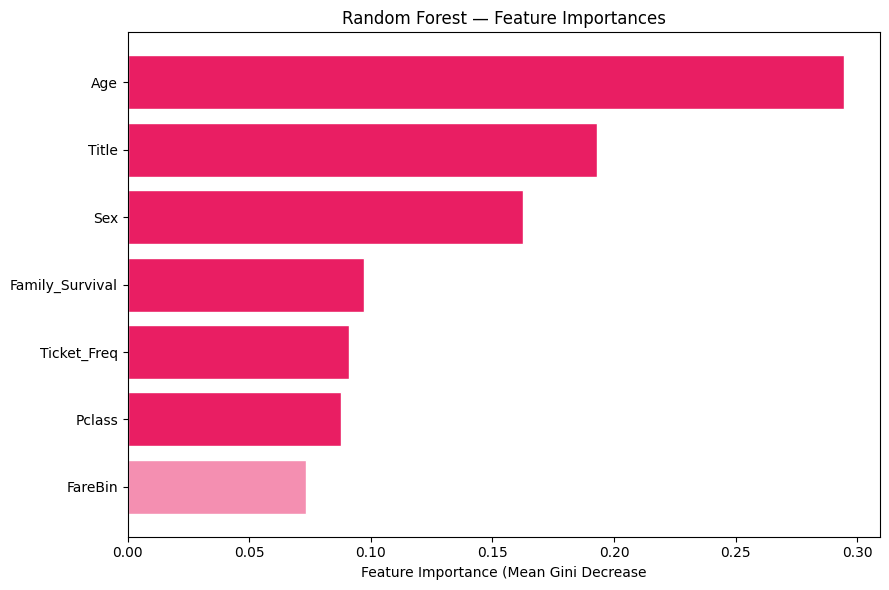

In [15]:
# Get Feature importances 
importances   = rf.feature_importances_ 
feature_names = X.columns.tolist() 

# Sort descending 
idx = np.argsort(importances)[::-1] 
sorted_names  = [feature_names[i] for i in idx] 
sorted_values = importances[idx] 

# Horizontal bar chart 
plt.figure(figsize=(9, 6)) 
colors = ['#E91E63' if v > 0.08 else '#F48FB1' for v in sorted_values] 
plt.barh(sorted_names[::-1], sorted_values[::-1], color=colors[::-1], edgecolor='white') 
plt.xlabel("Feature Importance (Mean Gini Decrease") 
plt.title("Random Forest — Feature Importances") 
plt.tight_layout() 
plt.show() 

In [16]:
# --- STEP 4: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [6, 7, 8],
    'min_samples_leaf': [3, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
grid.fit(X, y) #It identifies the combination of parameters that yielded the highest average validation score.
model = grid.best_estimator_  #Extracts the best-performing model

In [17]:
# Evaluate the hyperparameter optimized model

# Calculate scores on training and validation sets
rf_train_score = model.score(X_train, y_train)
rf_val_score = model.score(X_val, y_val)

print(f"RF Train Score: {rf_train_score:.2%}")
print(f"RF Validation Score: {rf_val_score:.2%}")

# Generate classification report for the validation set
print(f"\n--- Random Forest Classification Report (Validation Set) ---")
print(classification_report(
    y_val, model.predict(X_val),
    target_names=['Not Survived', 'Survived']))

RF Train Score: 85.67%
RF Validation Score: 85.47%

--- Random Forest Classification Report (Validation Set) ---
              precision    recall  f1-score   support

Not Survived       0.84      0.93      0.88       105
    Survived       0.89      0.74      0.81        74

    accuracy                           0.85       179
   macro avg       0.86      0.84      0.85       179
weighted avg       0.86      0.85      0.85       179



In [18]:
#Calculate accuracy on full training set (may indicate overfitting)
train_accuracy = model.score(X, y)

#Retrieve best mean cross-validation score (more reliable performance metric)
cv_score = grid.best_score_

print(f"Training Accuracy: {train_accuracy:.2%}")
print(f"Cross-Validation Accuracy (GridSearch): {cv_score:.2%}")

#Check for overfitting
if train_accuracy > cv_score + 0.05:
    print("Warning: Potential overfitting detected (Training > CV).")

Training Accuracy: 85.63%
Cross-Validation Accuracy (GridSearch): 85.18%


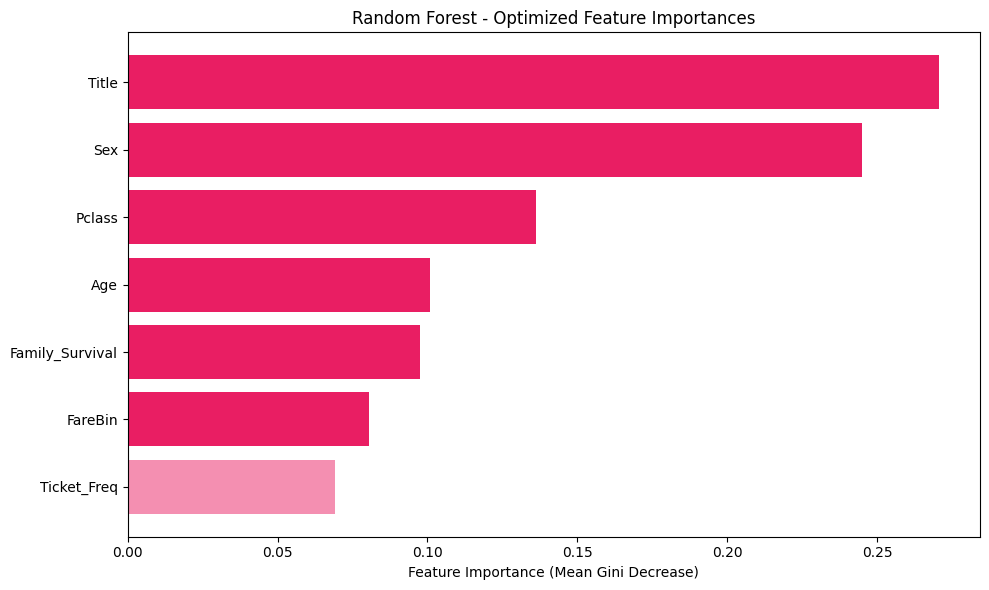

In [19]:
#Feature Importance on Optimized Model
importances = model.feature_importances_
feature_names = X.columns.tolist()

# 2. Organize and sort the data
# Creating a DataFrame makes sorting and plotting much cleaner
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) # Ascending=True for horizontal bar chart

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Apply the color logic from your screenshot
colors = ['#E91E63' if v > 0.08 else '#F48FB1' for v in feat_imp_df['Importance']]

plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
plt.xlabel("Feature Importance (Mean Gini Decrease)")
plt.title("Random Forest - Optimized Feature Importances")
plt.tight_layout()
plt.show()

In [20]:
# --- STEP 4: EXPLAIN PREDICTION
predictions = model.predict(X_test)


In [21]:
#Submission
output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': predictions.astype(int)})
output.to_csv('submission.csv', index=False)
print("Submission saved")

Submission saved
